# Transport provision

In [1]:
import geopandas as gpd
import momepy as mp
import osmnx as ox

import os
os.getcwd()

import pickle

## Data initialization

In [2]:
local_crs = 32637 # Tula region crs 

region_gdf = gpd.read_file("data/tula_region_districts.geojson").to_crs(local_crs)

with open("data/G_drive.pickle", "rb") as f:
    G_drive = pickle.load(f)

_, road_gdf = mp.nx_to_gdf(G_drive)
road_gdf.to_crs(local_crs, inplace = True)


airport = gpd.read_file("data/tula_region_aerodrome.geojson")
airport["geometry"] = airport.geometry.representative_point()
airport.to_crs(local_crs, inplace = True)

railways_gdf = gpd.read_file("data/tula_region_railway_edges.geojson").to_crs(local_crs)

towns_gdf = gpd.read_file("data/tula_region_towns.geojson").to_crs(local_crs)

<Axes: >

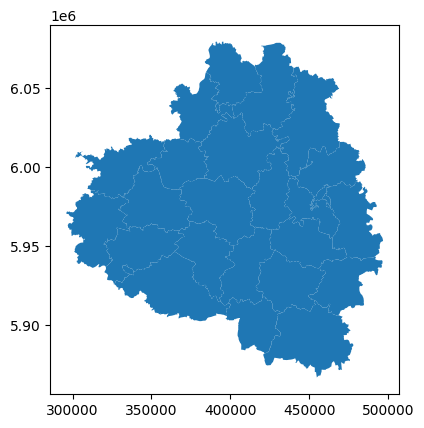

In [3]:
region_gdf.plot()

## Calculation

**Transport Provision Index**

The transport provision index shows how well a territory is served by transport infrastructure.

It is based on:
- road length in the territory,
- railway length in the territory,
- territory area,
- settlement area,
- distance to the nearest airport.

For each territory polygon, the index is calculated as:

`index = 0.4 * (rail_length_km / area_km2) + 0.3 * (road_length_km / area_km2) + 0.2 * (1 / airport_distance_km) + 0.1 * (1 - town_area_km2 / area_km2)`

If `airport_distance_km = 0`, it is replaced with `1` in the denominator to avoid division by zero.

A higher index means better transport provision.


In [4]:
from transport_frames.transport_provision import calculate_transport_provision

result = calculate_transport_provision(region_gdf, road_gdf, railways_gdf, airport, towns_gdf)
result.head()

,geometry,area_km2,road_length_km,rail_length_km,airport_distance_km,town_area_km2,transport_provision_index
0,"POLYGON ((319712.393 5950903.092, 319906.056 5...",1068.791430,437.932584,0.000000,46.158018,0.0,0.227257
1,"POLYGON ((296002.715 5971313.18, 296090.881 59...",1187.584940,642.533083,11.962991,76.482413,0.0,0.268957
2,"POLYGON ((424958.858 5954606.827, 425051.017 5...",959.136514,598.044699,65.348910,66.353928,0.0,0.317325
3,"POLYGON ((425947.184 6022267.642, 426062.021 6...",1626.599493,949.435076,82.880691,44.314850,0.0,0.300002
4,"POLYGON ((416123.449 5924160.895, 416677.559 5...",1073.618556,587.125980,74.272343,43.009392,0.0,0.296382


## Visualization

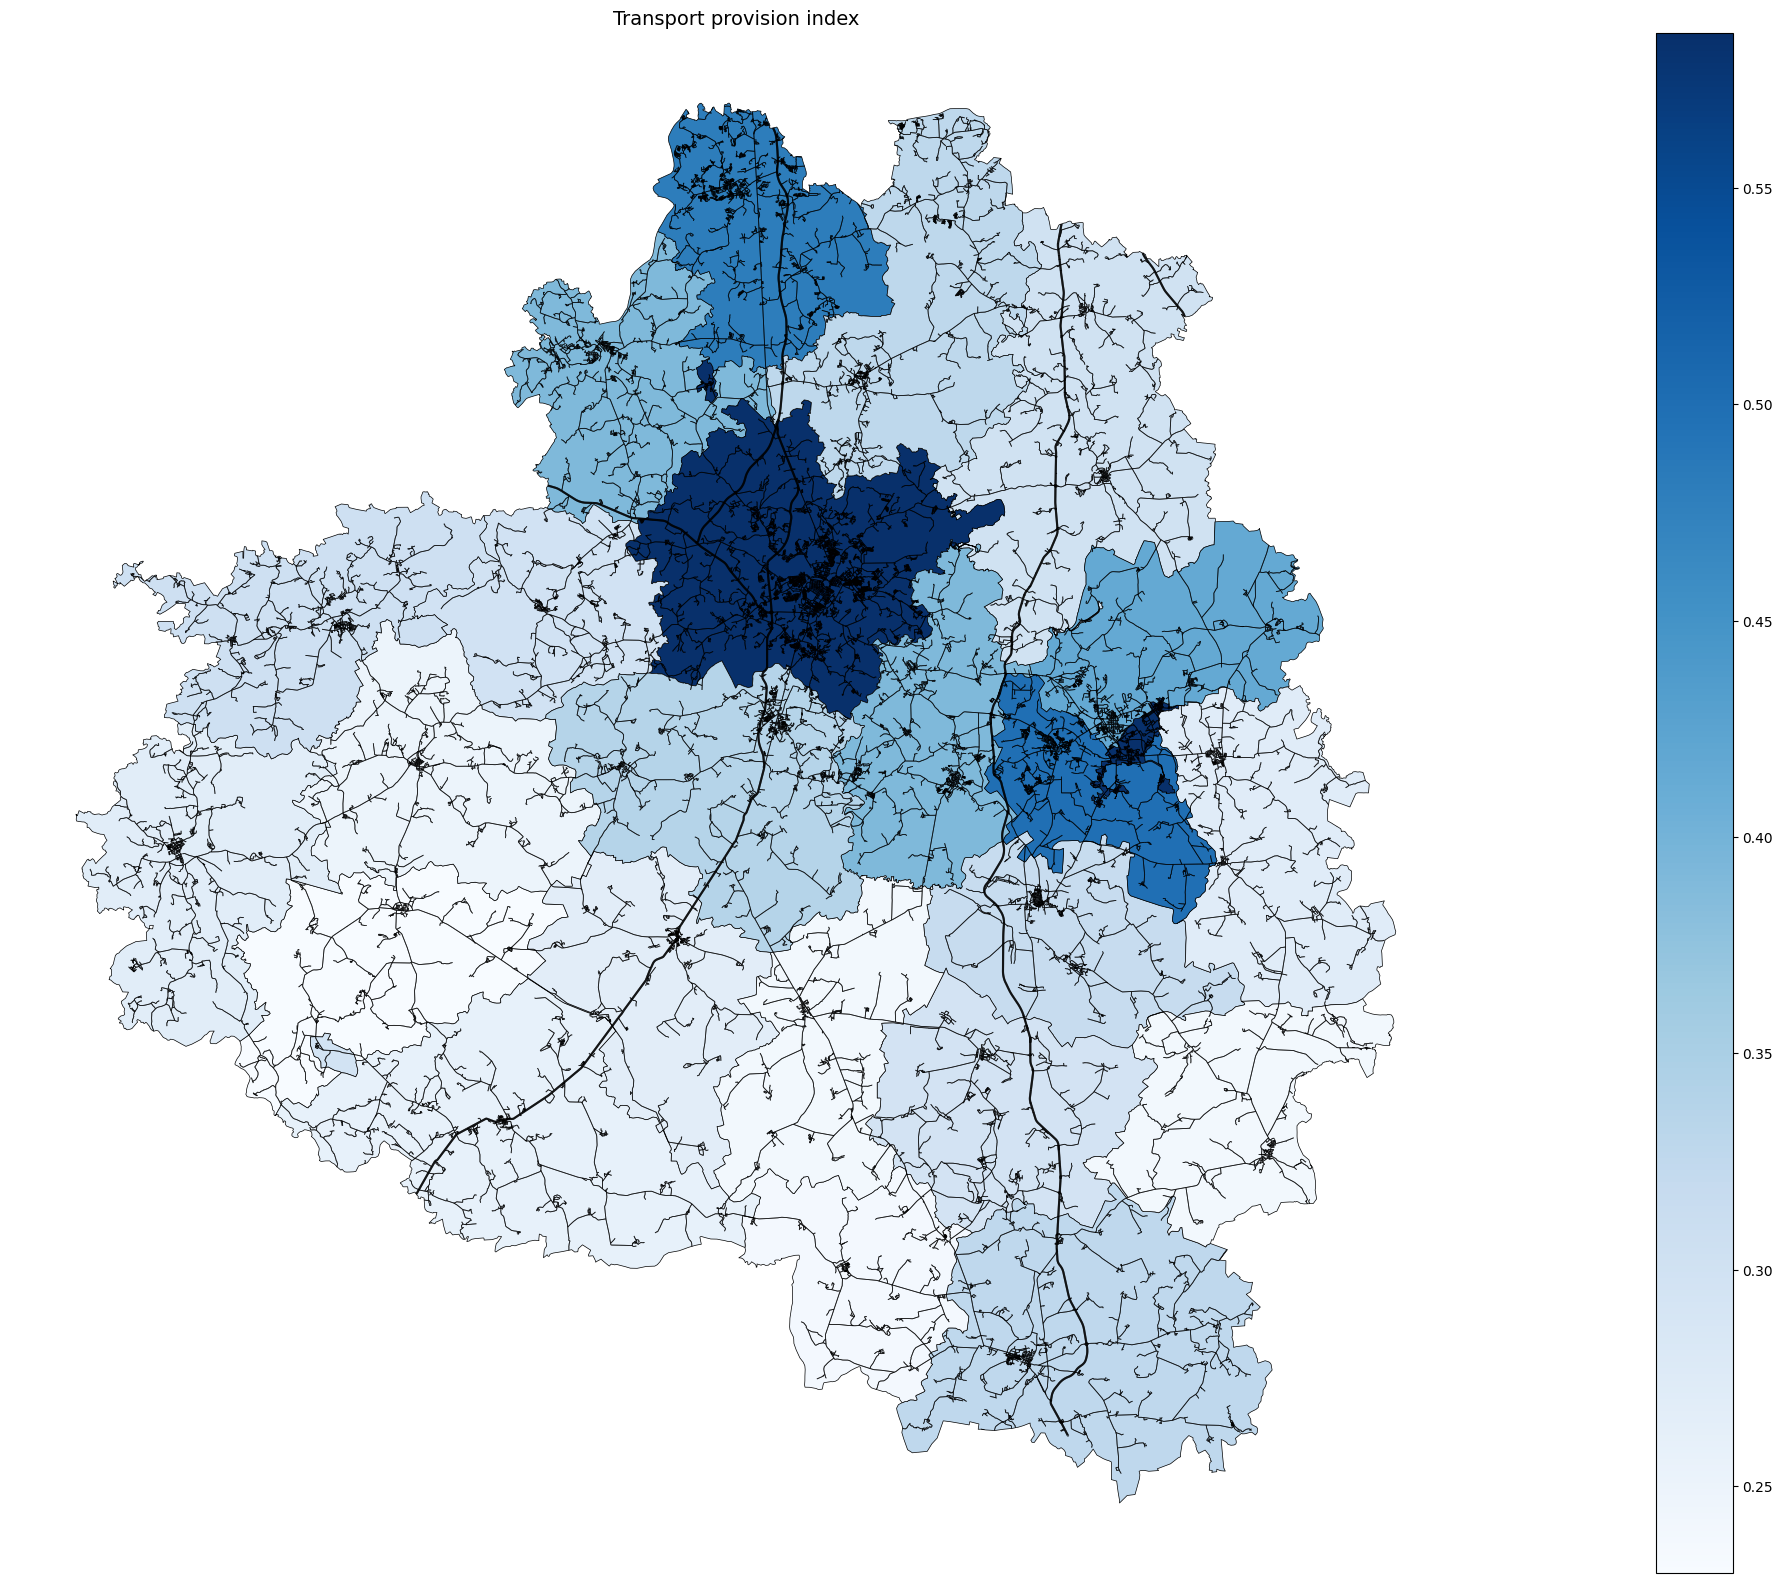

In [5]:
from transport_frames.transport_provision import visualize_transport_provision

visualize_transport_provision(result, road_gdf)